In [1]:
# -*- coding: utf-8 -*-
#  Copyright 2026 United Kingdom Research and Innovation
#
#  Licensed under the Apache License, Version 2.0 (the "License");
#  you may not use this file except in compliance with the License.
#  You may obtain a copy of the License at
#
#      http://www.apache.org/licenses/LICENSE-2.0
#
#  Unless required by applicable law or agreed to in writing, software
#  distributed under the License is distributed on an "AS IS" BASIS,
#  WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
#  See the License for the specific language governing permissions and
#  limitations under the License.
#
#  Authored by:    Laura Murgatroyd (UKRI-STFC)

# Neutron Starvation Artefacts


This notebook introduces neutron starvation artefacts.

In [2]:
from cil.utilities.display import show2D
import numpy as np
import matplotlib.pyplot as plt
import os
from cil.utilities.display import show1D
from data_io.io import read_mantid_imaging_data
from cil.utilities.jupyter import islicer, link_islicer
from cil.plugins.astra import FBP as FBP_ASTRA
from cil.processors import Slicer 
from cil.framework import DataContainer
from recon.weighted_fbp import run_weighted_fbp_parallel

import warnings
warnings.filterwarnings("ignore")

## Data

This notebook uses a dataset of a lego man imaged at IMAT. The lego man is inside a lead container.
You will need to download the dataset `preprocessed_data.zip` from https://zenodo.org/records/17814677:

    https://zenodo.org/records/17814677/files/preprocessed_data.zip

Please update the filepath below:

In [3]:
base_path = "/home/lhe97136/Data/Lego GR Investigation/Data for Release/preprocessed_data/"
# pixel size in cm, which is listed on the zenodo page:
pixel_size = 100*10**-4
equi_full = read_mantid_imaging_data(os.path.join(base_path, "Equidistant"), pixel_size=pixel_size)

In [4]:
equi_recon = run_weighted_fbp_parallel(equi_full)

## Neutron Starvation

'Neutron starvation' artefacts appear when there aren't enough neutrons reaching the detector as they have been stopped passing through a very attenuating material, or particularly long path length of attenuating material. The artefacts appear as streaks and dark regions in the reconstruction because lack of neutrons means lack of data we can reconstruct!


In X-ray CT the equivalent effect is 'Photon Starvation', which is sometimes known as 'metal artefacts' (as metal is very attenuating to X-rays).

## Example of Neutron Starvation Artefacts

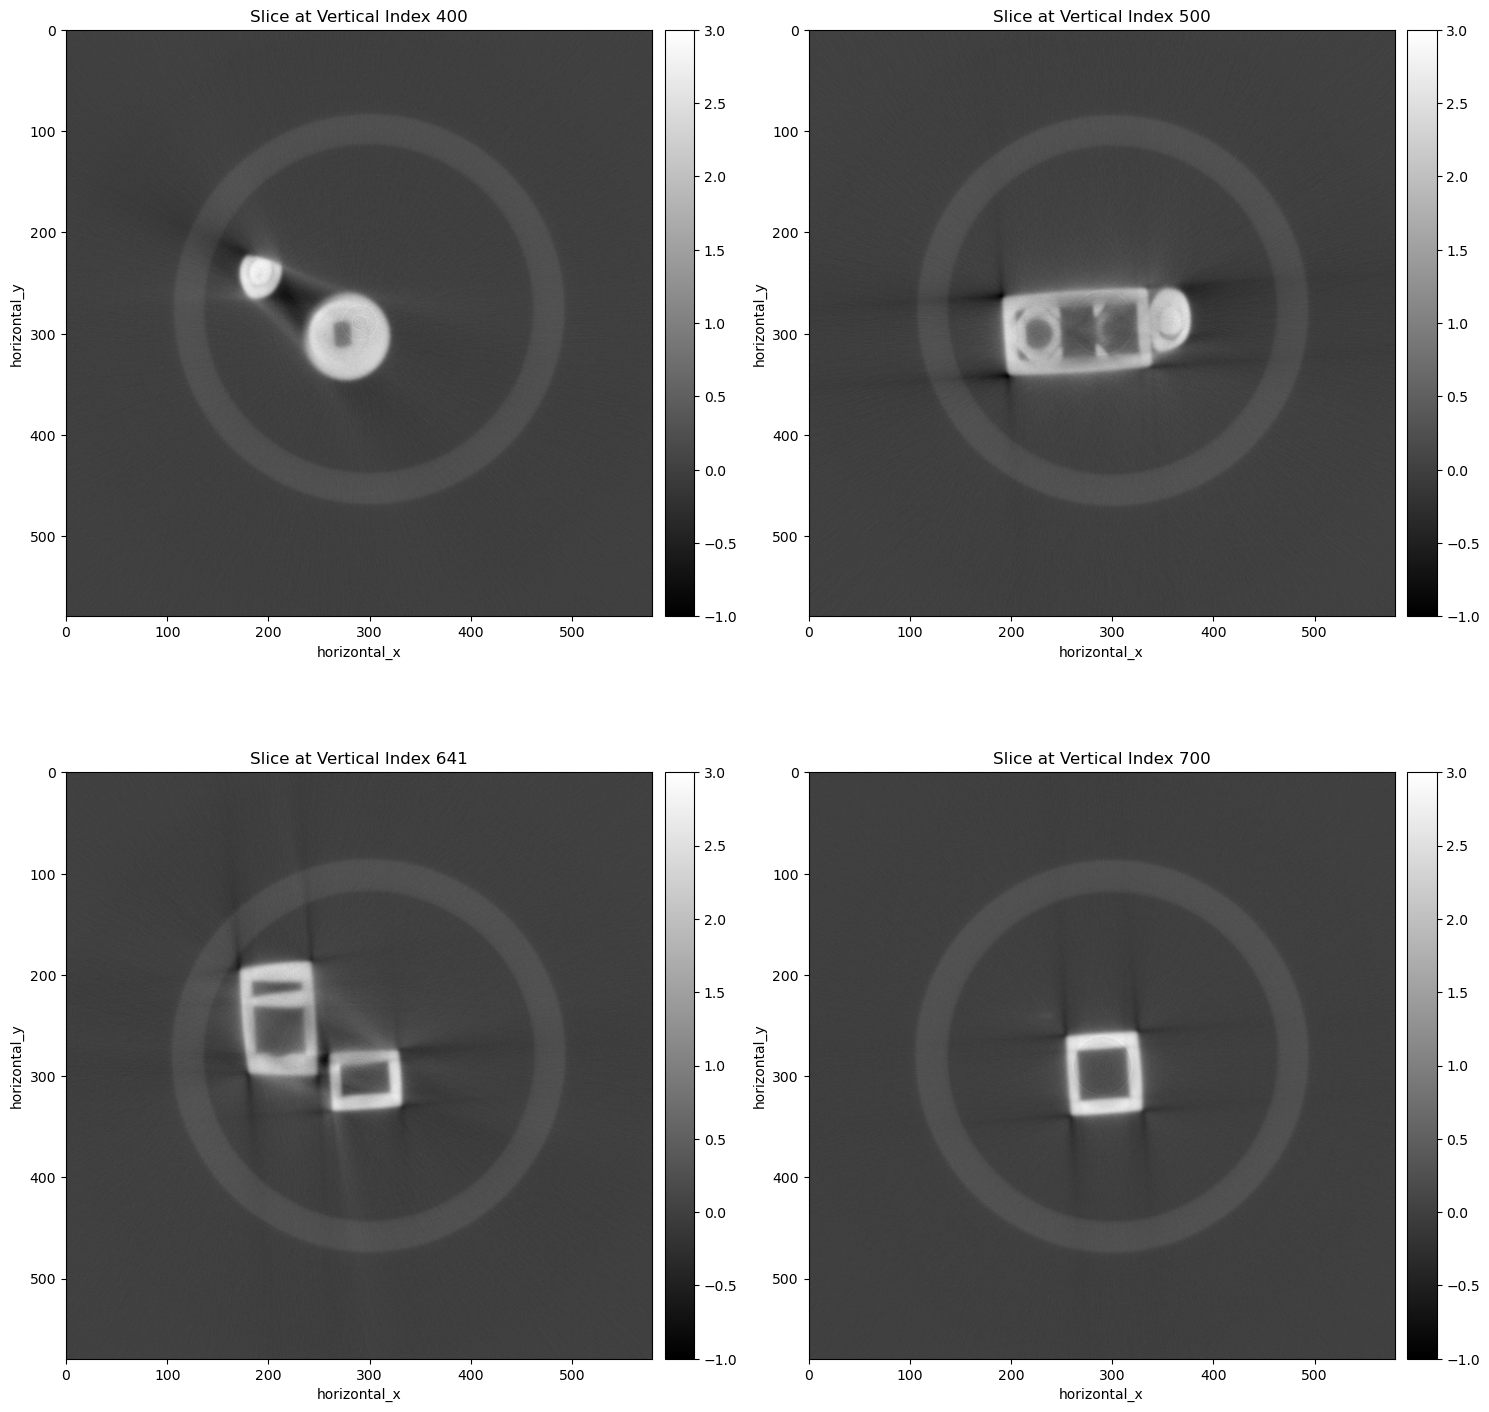

In [13]:
vertical_indices = [400, 500, 641,700]
show2D([equi_recon.get_slice(vertical=x) for x in vertical_indices], title=[f"Slice at Vertical Index {x}" for x in vertical_indices], origin='upper-left', cmap='gray', fix_range=(-1,3))

Slice 400 is a slice through the lego man's head and hand. There is a lack of neutrons that are able to pass through both the head and hand, so we see a dark region in the reconstruction between these two parts.

Similarly there are long path lengths through the edges of the body (Slice 500) and legs (Slice 641 and 700).

In 3 of the 4 slices shown above, the resulting artefacts even extend into the lead container (the ring).

## Iterative reconstruction results

Outside of this notebook we tried running some iterative algorithms on the data. We show the result of these below.

Total Variation regularisation enforces smooth regions and sharp boundaries, but it enforced the boundary between the artefact and sample or air, so did not help!

![iterative](./images/Artefacts_2_iterative.png)

Unfortunately neutron starvation is difficult to correct for and its better to prevent it in the first place through choice of sample material and how the sample is mounted.

## Transmission Levels

In lab-based X-ray CT you would have the capability of being able to change the scan parameters to alter the spectrum of X-ray energies. Ideally you'd want 10-90% transmission values through the sample.

Let's see if we have less than 10% transmission anywhere in this dataset:

Here we load in data which has already been preprocessed in Mantid Imaging, but not yet Transmission to Absorption Converted:

In [6]:
equi_full = read_mantid_imaging_data(os.path.join(base_path, "Equidistant"), pixel_size=pixel_size, convert_to_absorption=False)

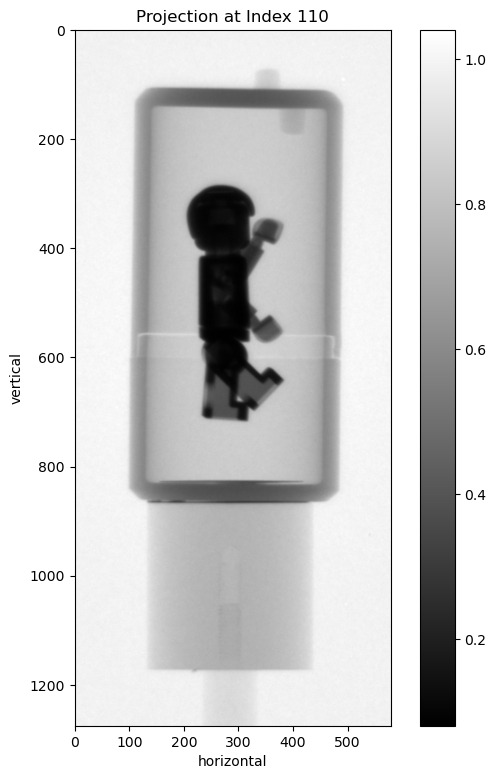

In [7]:
show2D(equi_full.get_slice(angle=110), title="Projection at Index 110", origin='upper-left')

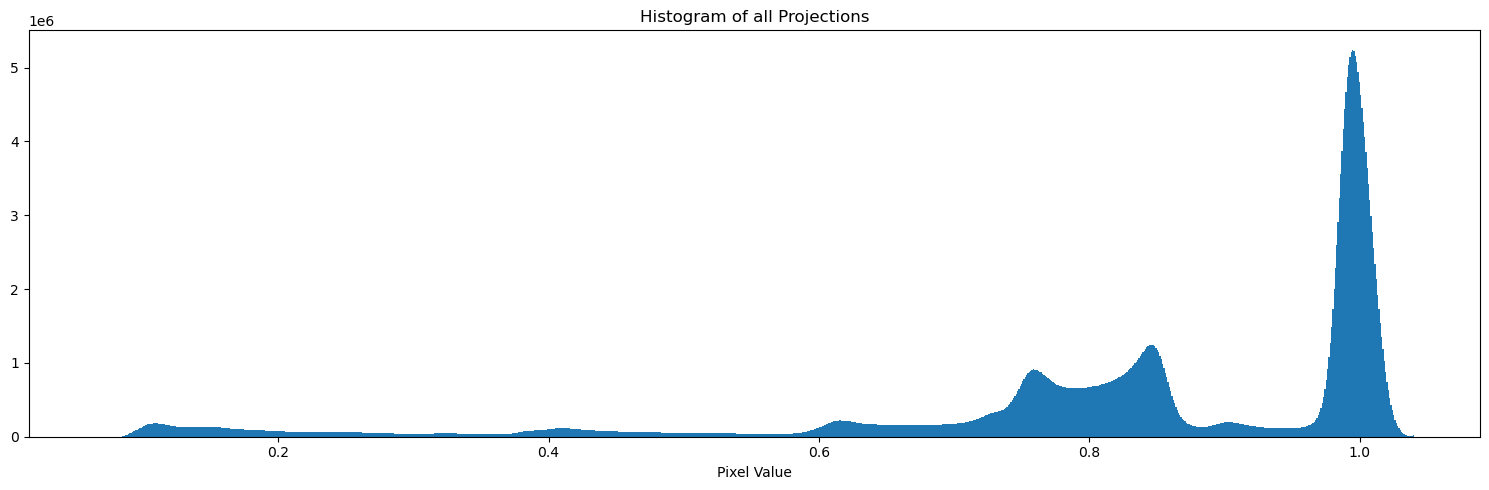

In [8]:
plt.figure(figsize=(15,5))

plt.hist(equi_full.as_array().flatten(), bins=1000)
plt.title(f"Histogram of all Projections")
plt.xlabel("Pixel Value")

plt.tight_layout()
plt.show()

We can use islicer to look at the 0-10% window, and see there's some data in this range in some projections:

In [9]:
islicer(equi_full, title='Projections', origin='upper-left', direction='angle', minmax=(0,0.1))

From investigations with islicer we identify the following projection numbers to look at:
110, 327, 360. In all of these, the Lego man's side is facing us.

Here we show in red overlayed on the image the pixels where we have less than 10% transmission and the histograms below this threshold:

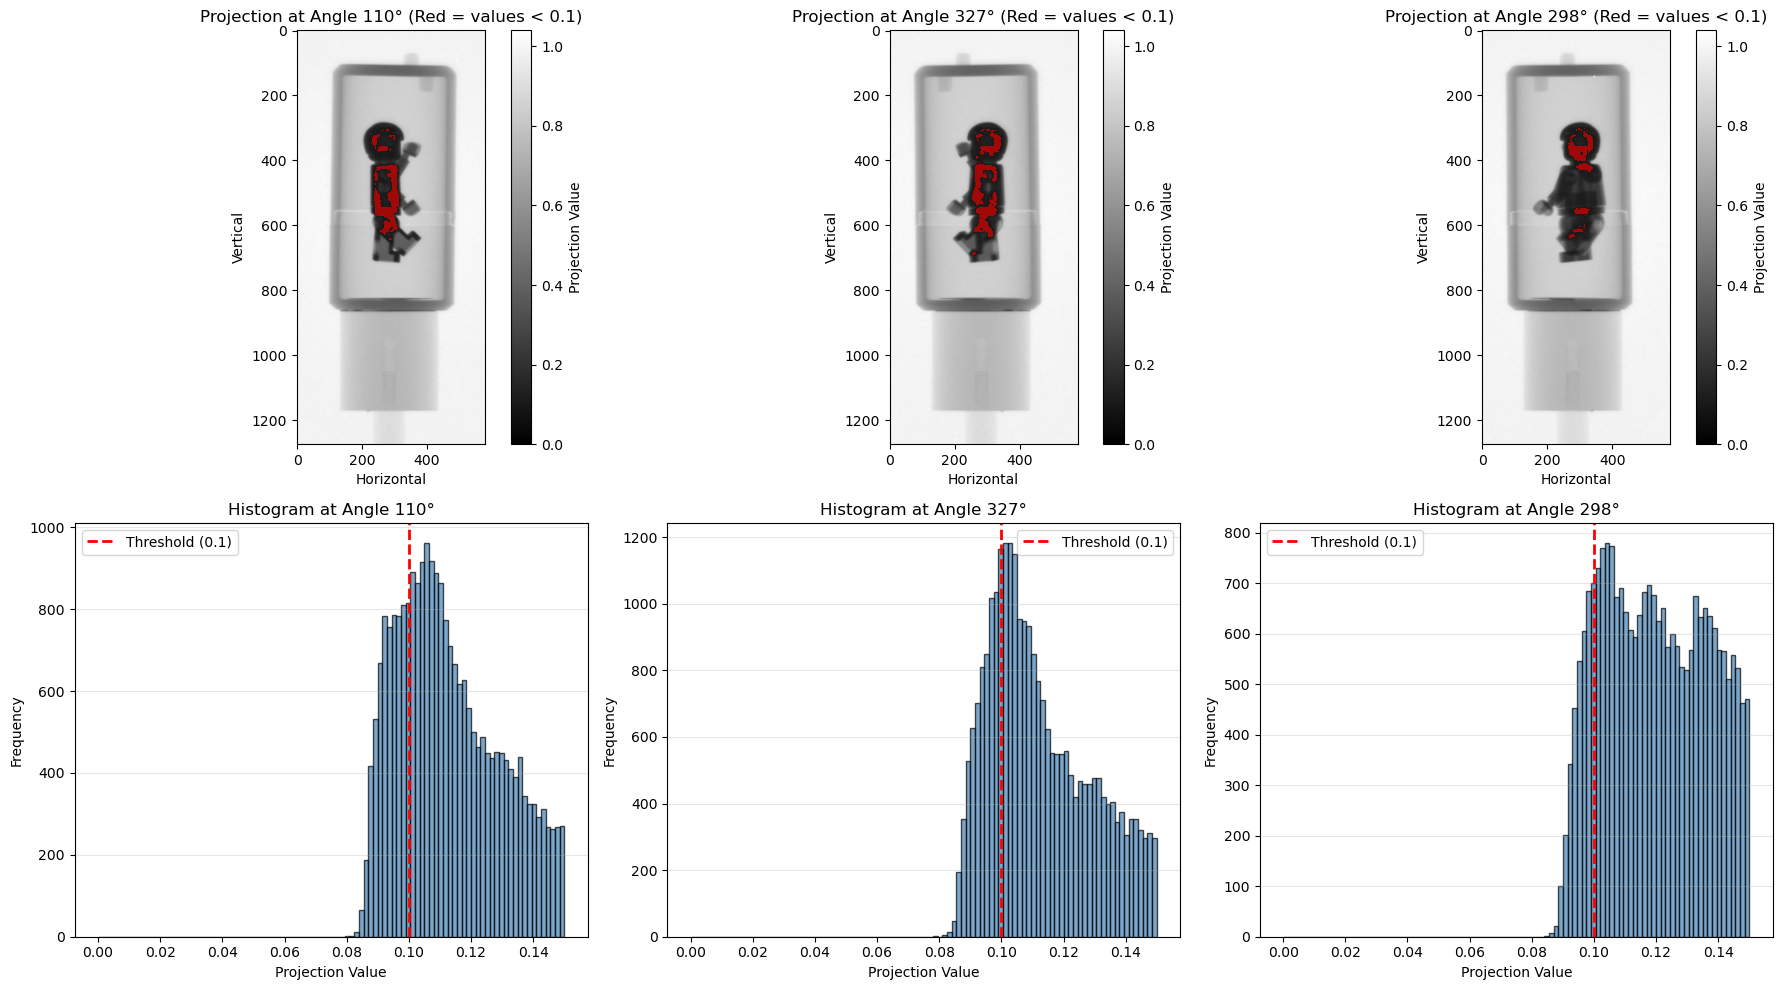

In [14]:
threshold = 0.1
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
angles_to_plot = [110, 327, 298]

for idx, angle in enumerate(angles_to_plot):
    proj = equi_full.get_slice(angle=angle).as_array()
    
    proj_display = proj.copy()
    low_value_mask = proj < threshold
    
    im = axes[0, idx].imshow(proj, cmap='grey', vmin=0)

    axes[0, idx].contourf(proj_display, levels=[0, threshold], colors=['red'], alpha=0.6)
    axes[0, idx].set_title(f'Projection at Angle {angle}° (Red = values < {threshold})')
    axes[0, idx].set_xlabel('Horizontal')
    axes[0, idx].set_ylabel('Vertical')
    plt.colorbar(im, ax=axes[0, idx], label='Projection Value')
    
    axes[1, idx].hist(proj.flatten(), bins=100, range=(0, threshold*1.5), color='steelblue', edgecolor='black', alpha=0.7)
    axes[1, idx].axvline(x=threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold ({threshold})')
    axes[1, idx].set_title(f'Histogram at Angle {angle}°')
    axes[1, idx].set_xlabel('Projection Value')
    axes[1, idx].set_ylabel('Frequency')
    axes[1, idx].legend()
    axes[1, idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


We can also plot the number of pixel values below 10% transmission for each projection:

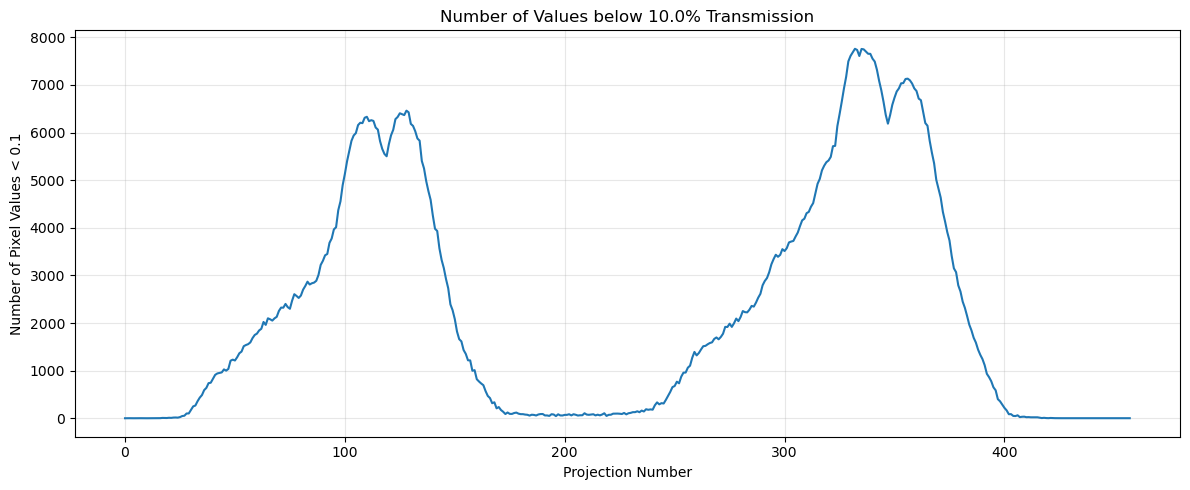

In [15]:
num_vals_below_thresh = []

for angle_idx in range(equi_full.geometry.angles.size):
    proj = equi_full.get_slice(angle=angle_idx).as_array()
    count_below = np.sum(proj < threshold)
    num_vals_below_thresh.append(count_below)

# Plot
plt.figure(figsize=(12, 5))
plt.plot(num_vals_below_thresh, linewidth=1.5)
plt.xlabel('Projection Number')
plt.ylabel(f'Number of Pixel Values < {threshold}')
plt.title(f'Number of Values below {threshold*100}% Transmission')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
